# Neg-t-SNE spectrum & baselines (MNIST)

## Mục lục

1. [Configuration](#Configuration)
2. [Thiết kế thực nghiệm](#Thiết-kế-thực-nghiệm)
3. [Load MNIST](#Load-MNIST)
4. [Neg-t-SNE spectrum](#Neg-t-SNE-spectrum)
5. [Baseline t-SNE & UMAP](#Baseline-t-SNE--UMAP)
6. [So sánh trực quan](#So-sánh-trực-quan)
7. [Nhận xét](#Nhận-xét)

Paper: *From t-SNE to UMAP with contrastive learning* (Damrich et al., ICLR 2023) — Fig. 1 (spectrum $\bar{Z}$) + so sánh sklearn t-SNE / UMAP trên cùng subset MNIST.

# Configuration

In [1]:
import sys
from pathlib import Path


def _lab_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "pyproject.toml").is_file() and (d / "code" / "data" / "load_data.py").is_file():
            return d
    raise RuntimeError("cd to lab-2 (pyproject.toml), then re-run.")


lab_root = _lab_root()
sys.path.insert(0, str(lab_root / "code"))
print(f"Lab root: {lab_root}")

Lab root: D:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2


In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from models.neg_tsne import fit_neg_tsne_spectrum, z_bars_spectrum, z_ee, z_tsne
from models.t_sne import TSNE as ScratchTSNE
from models.umap import UMAP as ScratchUMAP
from experiments.utils import (
    plot_embedding_scatter,
    results_to_dataframe,
    run_baseline_for_method,
)

from experiments.utils import plot_embedding_spectrum

try:
    import torch

    print("CUDA:", torch.cuda.is_available())
except ImportError:
    print("PyTorch not installed")

d:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA: False


In [3]:
SEED = 0

# --- Neg-t-SNE (contrastive-ne / CNE) ---
K = 15
NEG_SAMPLES = 5
N_EPOCHS = 500
BATCH_SIZE = 1024
DEVICE = "auto"
DATA_ON_GPU = False
QUICK_TEST = True

# --- Baseline t-SNE / UMAP (cùng style baseline.ipynb) ---
EXPERIMENT = {
    "trustworthiness_k": 12,
    "knn_k": 5,
    "tsne_perplexity": 30,
    "tsne_max_iter": 750,
    "umap_neighbors": K,
    "umap_min_dist": 0.1,
}

if QUICK_TEST:
    N_EPOCHS = 50
    BATCH_SIZE = 512
    EXPERIMENT["tsne_max_iter"] = 500

# Thiết kế thực nghiệm

| Thành phần | Mô tả |
|------------|--------|
| **Neg-t-SNE** | [`NegTSNE`](../models/neg_tsne.py) → `cne.CNE`, đồ thị kNN **sklearn** (`graph=...`) |
| **Spectrum** | EE tại $\bar{Z}=n^2/m$, sau đó `geomspace(100n,\, n^2/m)` (mốc t-SNE → UMAP) |
| **t-SNE / UMAP** | Wrapper sklearn / umap-learn; `run_baseline_for_method` như [`baseline.ipynb`](baseline.ipynb) |
| **Metrics** | `trustworthiness@12`, `knn_accuracy@5`, `fit_time_s` |

| | Full (paper) | `QUICK_TEST=True` (mặc định) |
|--|--|--|
| Samples | 70 000 | 5 000 |
| `n_epochs` | 500 | 50 |
| $\bar{Z}$ | `geomspace(100n, n²/m, 9)` | `geomspace(100n, n²/m, 5)` |

Cài đặt: `uv sync` — xem [`README.md`](../../README.md). Dữ liệu: `code/data/raw/mnist.hdf5`.

# Load MNIST

In [4]:
data_path = lab_root / "code" / "data" / "raw" / "mnist.hdf5"
if not data_path.is_file():
    raise FileNotFoundError(f"Place MNIST at {data_path}")

with h5py.File(data_path, "r") as hf:
    X_train = np.asarray(hf["items/1/items/1/rcargs/items/0"], dtype=np.float32)
    y_train = np.asarray(
        hf["items/1/items/1/rcargs/items/1/items/0/items/1/rcargs/items/0"],
        dtype=np.int64,
    )
    X_test = np.asarray(hf["items/0/items/1/rcargs/items/0"], dtype=np.float32)
    y_test = np.asarray(
        hf["items/0/items/1/rcargs/items/1/items/0/items/1/rcargs/items/0"],
        dtype=np.int64,
    )
    X = np.vstack([X_train, X_test]) / 255.0
    y = np.concatenate([y_train, y_test])

if QUICK_TEST:
    idx = np.random.default_rng(SEED).choice(len(X), size=min(5000, len(X)), replace=False)
    X, y = X[idx], y[idx]
    print("QUICK_TEST: using 5,000-sample subset")

n_samples = len(X)
n_z_points = 5 if QUICK_TEST else 9
Z_BARS = z_bars_spectrum(n_samples, NEG_SAMPLES, n_points=n_z_points)
print(f"MNIST: X={X.shape}, y={y.shape}")
print(f"Z_tsne={z_tsne(n_samples):.3e}, Z_umap={z_ee(n_samples, NEG_SAMPLES):.3e}")
print("Z_bar:", ", ".join(f"{z:.0e}" for z in Z_BARS))

QUICK_TEST: using 5,000-sample subset
MNIST: X=(5000, 784), y=(5000,)
Z_tsne=5.000e+05, Z_umap=5.000e+06
Z_bar: 5e+05, 9e+05, 2e+06, 3e+06, 5e+06


# Neg-t-SNE spectrum

Early exaggeration rồi lần lượt fit với từng $\bar{Z}$ (Damrich et al., Fig. 1).

In [5]:
embeddings, runtimes_min, init_ee = fit_neg_tsne_spectrum(
    X,
    Z_BARS,
    k=K,
    negative_samples=NEG_SAMPLES,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    seed=SEED,
    device=DEVICE,
    data_on_gpu=DATA_ON_GPU,
    verbose=True,
)

print("\nRuntimes (min), main phase:")
for z, t in sorted(runtimes_min.items()):
    print(f"  Z_bar={z:.3e}: {t:.1f}")

Building kNN graph (k=15) with sklearn...
n=5,000 | EE: Z_bar=5.000e+06, epochs=16


Finished epoch 0/16, loss 1233.099
Finished epoch 3/16, loss 780.902
Finished epoch 6/16, loss 741.145
Finished epoch 9/16, loss 718.451
Finished epoch 12/16, loss 702.124
Finished epoch 15/16, loss 688.878


EE finished in 0.1 min

=== Z_bar = 5.000e+05 (34 epochs) ===


Finished epoch 0/34, loss 804.688
Finished epoch 6/34, loss 566.597
Finished epoch 12/34, loss 546.248
Finished epoch 18/34, loss 535.667
Finished epoch 24/34, loss 529.751
Finished epoch 30/34, loss 523.980


Done in 0.2 min

=== Z_bar = 8.891e+05 (34 epochs) ===


...

Done in 0.2 min

=== Z_bar = 2.812e+06 (34 epochs) ===


Finished epoch 0/34, loss 693.429
Finished epoch 6/34, loss 666.887
Finished epoch 12/34, loss 648.722
Finished epoch 18/34, loss 633.976
Finished epoch 24/34, loss 622.543
Finished epoch 30/34, loss 611.851


Done in 0.2 min

=== Z_bar = 5.000e+06 (34 epochs) ===


Finished epoch 0/34, loss 788.463
Finished epoch 6/34, loss 764.486
Finished epoch 12/34, loss 738.308
Finished epoch 18/34, loss 717.949
Finished epoch 24/34, loss 702.538
Finished epoch 30/34, loss 690.224


Done in 0.2 min

Runtimes (min), main phase:
  Z_bar=5.000e+05: 0.2
  Z_bar=8.891e+05: 0.2
  Z_bar=1.581e+06: 0.2
  Z_bar=2.812e+06: 0.2
  Z_bar=5.000e+06: 0.2


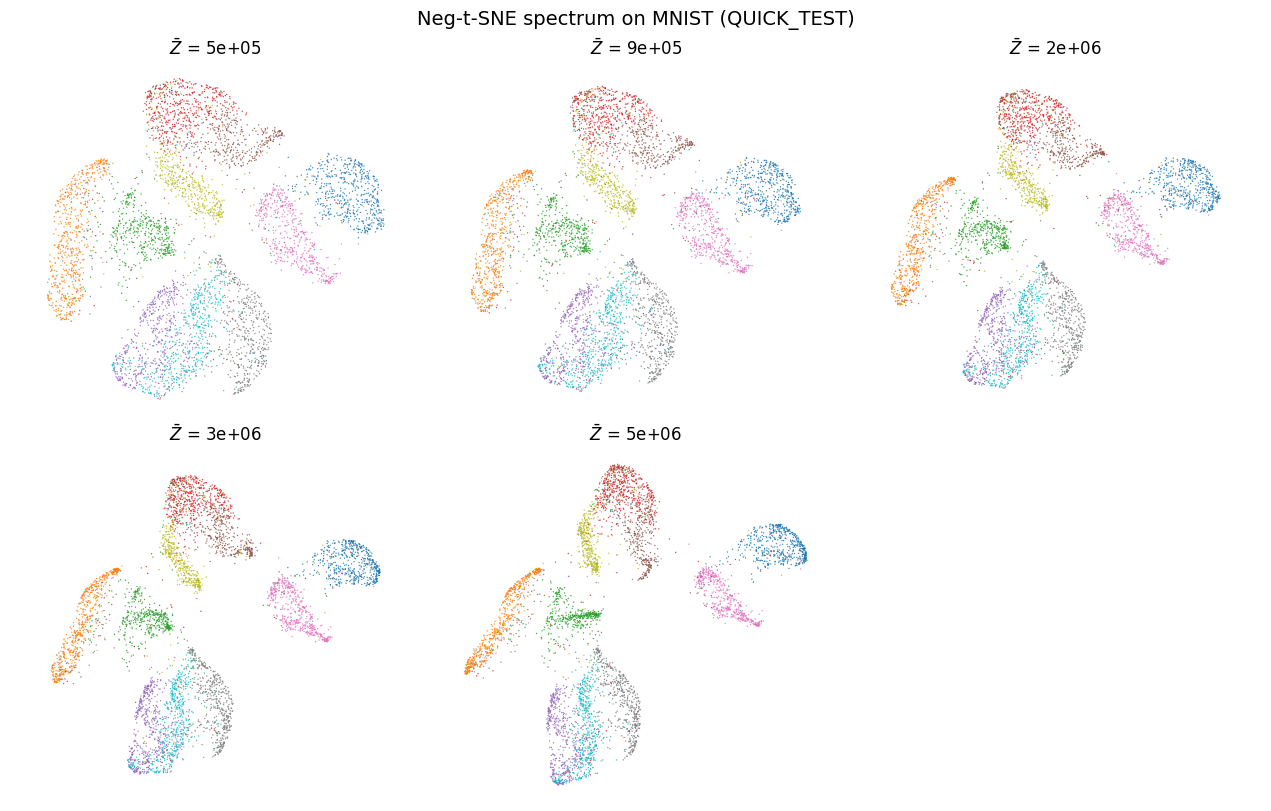

In [6]:
title = "Neg-t-SNE spectrum on MNIST"
if QUICK_TEST:
    title += " (QUICK_TEST)"
plot_embedding_spectrum(embeddings, y, Z_BARS, suptitle=title)
plt.show()

# Baseline t-SNE & UMAP

Cùng subset MNIST. `MNIST_DATASETS` truyền pixel 0–255 vì `preprocess_for_dataset("mnist", ...)` trong [`utils.py`](utils.py) chia 255.

In [7]:
MNIST_DATASETS = {"mnist": (X * 255.0, y)}
DATASET_ORDER = ("mnist",)


def _tsne_factory():
    return ScratchTSNE(
        n_components=2,
        perplexity=EXPERIMENT["tsne_perplexity"],
        max_iter=EXPERIMENT["tsne_max_iter"],
        init="pca",
        random_state=SEED,
    )


tsne_rows, tsne_emb, _ = run_baseline_for_method(
    "t-SNE",
    _tsne_factory,
    MNIST_DATASETS,
    DATASET_ORDER,
    EXPERIMENT,
)
umap_rows, umap_emb, _ = run_baseline_for_method(
    "UMAP",
    lambda: ScratchUMAP(
        n_neighbors=EXPERIMENT["umap_neighbors"],
        min_dist=EXPERIMENT["umap_min_dist"],
        n_components=2,
        random_state=SEED,
    ),
    MNIST_DATASETS,
    DATASET_ORDER,
    EXPERIMENT,
)

Y_tsne = tsne_emb["mnist"]
Y_umap = umap_emb["mnist"]
display(results_to_dataframe(tsne_rows + umap_rows))

d:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,trustworthiness@12,knn_accuracy@5,fit_time_s,dataset,method,n_samples
0,0.9779,0.9172,6.8366,mnist,t-SNE,5000
1,0.9580,0.8916,20.2757,mnist,UMAP,5000


# So sánh trực quan

Hàng trên: baseline **sklearn t-SNE** và **umap-learn** (thuật toán riêng, không trùng CNE).

Hàng dưới: Neg-t-SNE tại $\bar{Z}=100n$ (**t-SNE-like**) và tại $\bar{Z}=n^2/m$ (**UMAP-like**). Với $n{=}5000$, $m{=}5$: $100n=5\times10^5$, $n^2/m=5\times10^6$.

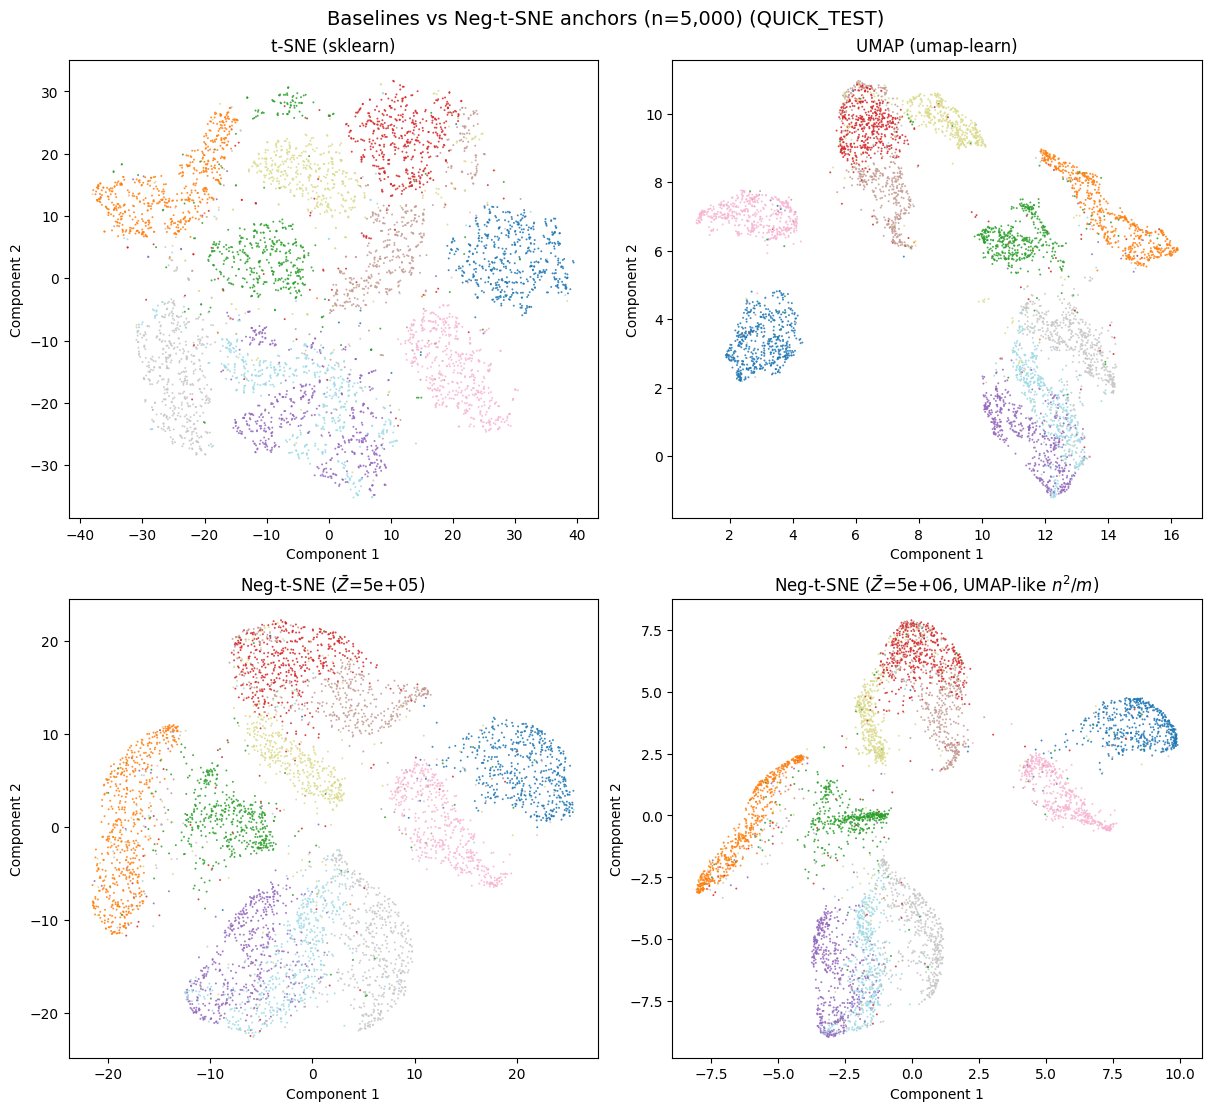

Spectrum keys: ['5e+05', '9e+05', '2e+06', '3e+06', '5e+06']
t-SNE-like panel: Z_bar=5.000e+05 (= 100n)
UMAP-like panel: Z_bar=5.000e+06 (= n^2/m)


In [8]:
quick_suffix = " (QUICK_TEST)" if QUICK_TEST else ""
point_size = 2.0 if n_samples <= 10_000 else 0.8
z_low = z_tsne(n_samples)
z_umap = z_ee(n_samples, NEG_SAMPLES)

fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
plot_embedding_scatter(Y_tsne, y, title="t-SNE (sklearn)", ax=axes[0, 0], s=point_size, alpha=0.85, show=False)
plot_embedding_scatter(Y_umap, y, title="UMAP (umap-learn)", ax=axes[0, 1], s=point_size, alpha=0.85, show=False)
plot_embedding_scatter(
    embeddings[z_low],
    y,
    title=rf"Neg-t-SNE ($\bar{{Z}}$={z_low:.0e})",
    ax=axes[1, 0],
    s=point_size,
    alpha=0.85,
    show=False,
)
plot_embedding_scatter(
    embeddings[z_umap],
    y,
    title=rf"Neg-t-SNE ($\bar{{Z}}$={float(z_umap):.0e}, UMAP-like $n^2/m$)",
    ax=axes[1, 1],
    s=point_size,
    alpha=0.85,
    show=False,
)
fig.suptitle(
    f"Baselines vs Neg-t-SNE anchors (n={n_samples:,}){quick_suffix}",
    fontsize=14,
)
plt.show()

print(f"Spectrum keys: {[f'{z:.0e}' for z in Z_BARS]}")
print(f"t-SNE-like panel: Z_bar={z_low:.3e} (= 100n)")
print(f"UMAP-like panel: Z_bar={float(z_umap):.3e} (= n^2/m)")

# Nhận xét

- **Không kỳ vọng khớp pixel-perfect:** Neg-t-SNE (CNE) là *họ* embedding; sklearn t-SNE / umap-learn là hai thuật toán khác.
- **$\bar{Z}$ nhỏ** → cục bộ hơn (gần t-SNE); **$\bar{Z} \approx n^2/m$** → toàn cục hơn (gần UMAP); **$\bar{Z}$ quá lớn** ($10^8$ trong QUICK_TEST) thường *không* giống UMAP baseline.
- **QUICK_TEST** (5k, 50 epoch): chưa đủ như paper (70k, 500 epoch) — hình chỉ định tính.
- **Cách đọc:** spectrum chạy từ $\bar{Z}=100n$ (t-SNE-like) đến $\bar{Z}=n^2/m$ (UMAP-like); so sánh hai đầu với sklearn t-SNE / UMAP (Damrich et al., 2023).